# Japanese Residential Property Market Analysis (2005–2024)

This notebook explores residential land and building transaction data 
across Japan over a 20-year period. The goal is to understand price 
trends, regional differences, and key factors that influence property 
prices — and ultimately build a predictive model.

**Dataset:** 1.3M transactions | Source: Japan Ministry of Land, 
Infrastructure, Transport and Tourism (MLIT)

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis-eda)
3. [Data Cleaning](#3-data-cleaning)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Building](#5-model-building)
6. [Conclusions](#6-conclusions)
7. [Saving the Model](#7-saving-the-model-and-clean-dataset)

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('data/All_prefectures_buildings_with_migration.csv')

print(f"Dataset shape: {df.shape}")
print(f"Years covered: {df['Year'].min()} – {df['Year'].max()}")
print(f"Total transactions: {len(df):,}")

Dataset shape: (1339147, 32)
Years covered: 2005 – 2024
Total transactions: 1,339,147


## 2. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data.
Let's start by examining the price distribution and key statistics.

In [5]:
print(df['TotalTransactionValue'].describe().apply(lambda x: f"¥{x:,.0f}"))

count         ¥1,339,147
mean         ¥32,084,765
std          ¥72,528,519
min                 ¥100
25%          ¥13,000,000
50%          ¥25,000,000
75%          ¥37,000,000
max      ¥31,000,000,000
Name: TotalTransactionValue, dtype: object


### 2.1 Price Distribution

The price data shows clear signs of outliers:
- **Minimum value of ¥100** is logically impossible for a real estate 
  transaction — likely a data entry error
- **Maximum value of ¥31 billion** is an extreme outlier that pulls 
  the mean (¥32M) significantly above the median (¥25M)
- The median (¥25M) is a more reliable measure of a typical transaction

In the next step, we will remove these outliers to get a cleaner picture 
of the market.

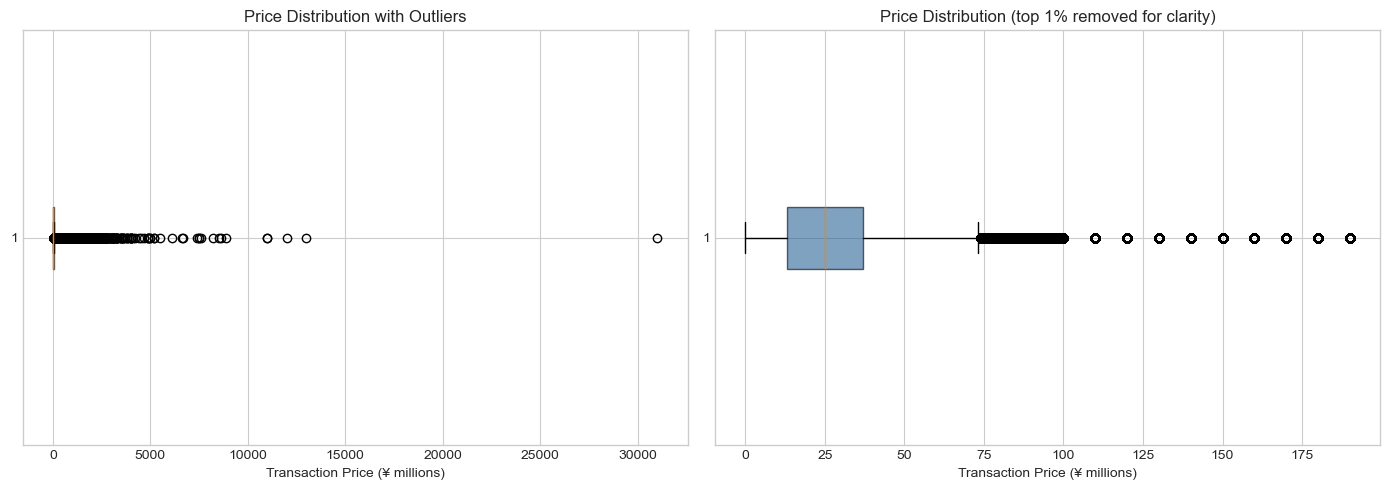

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['TotalTransactionValue'] / 1_000_000, 
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#2a6496', alpha=0.6))
axes[0].set_title('Price Distribution with Outliers')
axes[0].set_xlabel('Transaction Price (¥ millions)')

q99 = df['TotalTransactionValue'].quantile(0.99)
axes[1].boxplot(df[df['TotalTransactionValue'] <= q99]['TotalTransactionValue'] / 1_000_000,
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#2a6496', alpha=0.6))
axes[1].set_title('Price Distribution (top 1% removed for clarity)')
axes[1].set_xlabel('Transaction Price (¥ millions)')

plt.tight_layout()
plt.show()

### Observations

The boxplot reveals the following:
- The majority of transactions are concentrated between ¥13M and ¥37M
- Even after removing the top 1%, there are still many high-value outliers 
  visible as individual points to the right
- The distribution is right-skewed: a small number of expensive properties 
  pull the mean above the median
- We will use the cleaned dataset (top 1% removed) for all further analysis

### 2.2 Price Trends Over Time

How have property prices changed over 20 years? 
We look at the median price per year to track market trends.

In [10]:
import os
os.makedirs('visuals', exist_ok=True)

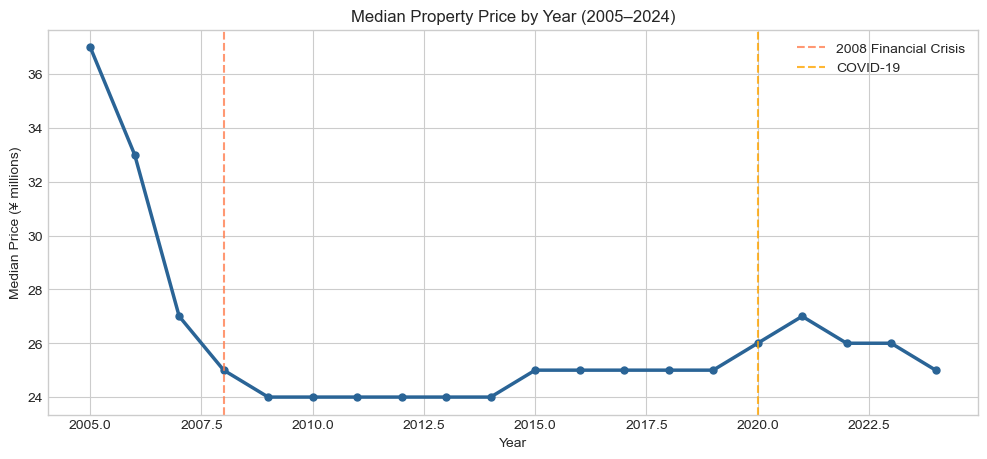

In [11]:
price_by_year = df.groupby('Year')['TotalTransactionValue'].median() / 1_000_000

plt.figure(figsize=(12, 5))
plt.plot(price_by_year.index, price_by_year.values,
         marker='o', color='#2a6496', linewidth=2.5, markersize=5)

plt.axvline(x=2008, color='coral', linestyle='--', alpha=0.8, label='2008 Financial Crisis')
plt.axvline(x=2020, color='orange', linestyle='--', alpha=0.8, label='COVID-19')

plt.title('Median Property Price by Year (2005–2024)')
plt.xlabel('Year')
plt.ylabel('Median Price (¥ millions)')
plt.legend()
plt.savefig('visuals/price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

The price trend reveals an important economic story:

- Prices were already declining before 2008, reflecting the long aftermath 
  of Japan's real estate bubble that burst in 1991
- Japan experienced two "Lost Decades" of falling asset prices — 
  a phenomenon unique in modern economic history
- After 2012, prices stabilized due to "Abenomics" — the economic stimulus 
  policy introduced by Prime Minister Shinzo Abe
- COVID-19 (2020) caused a brief spike, likely driven by increased demand 
  for larger homes as remote work became common
- By 2024, prices show a slight decline from the post-COVID peak

This context is crucial for modeling: price is not only driven by property 
characteristics, but also by macroeconomic conditions.

### 2.3 Regional Price Differences

Japan is a geographically diverse country. 
Let's examine how property prices vary across prefectures.

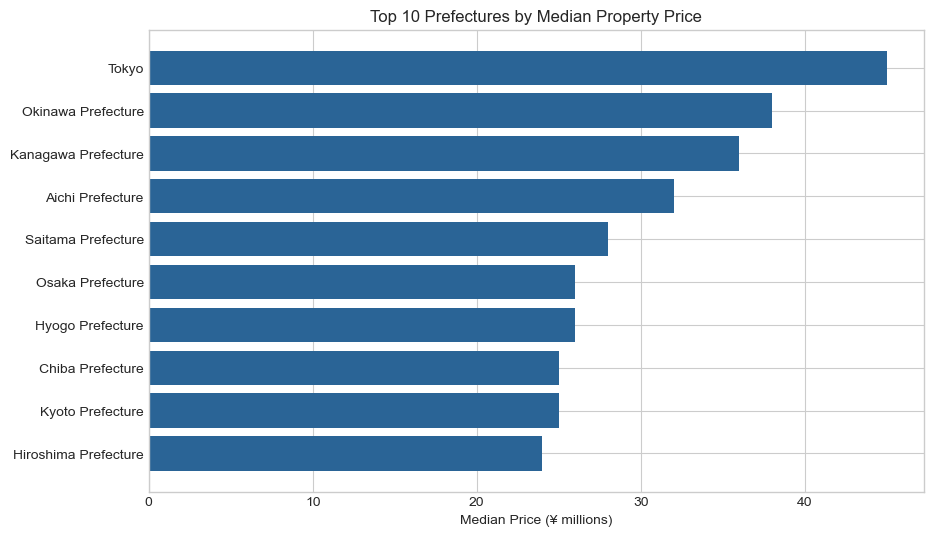

In [14]:
top_pref = (df.groupby('Prefecture')['TotalTransactionValue']
              .median()
              .sort_values(ascending=False)
              .head(10) / 1_000_000)

plt.figure(figsize=(10, 6))
plt.barh(top_pref.index[::-1], top_pref.values[::-1], color='#2a6496')
plt.title('Top 10 Prefectures by Median Property Price')
plt.xlabel('Median Price (¥ millions)')
plt.savefig('visuals/price_by_prefecture.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Tokyo** leads by a significant margin — as the capital and economic 
  center, this is expected
- **Okinawa** ranks second, which is surprising at first glance. 
  This is likely driven by three factors: the large US military presence 
  creating steady housing demand, growing tourism and investment activity, 
  and limited land supply as an island prefecture
- The remaining prefectures (Kanagawa, Aichi, Saitama) are all part of 
  major metropolitan areas — Tokyo and Nagoya corridors
- Regional location appears to be a strong predictor of price, 
  which we will confirm in the modeling stage

### 2.4 Price vs Property Area

Does a larger property always mean a higher price? 
Let's examine the relationship between area and transaction value.

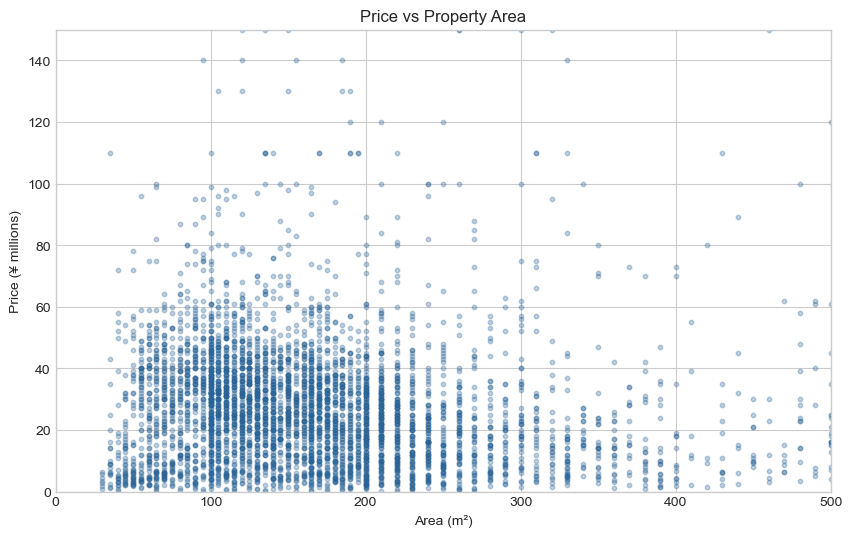

In [17]:
sample = df[df['TotalTransactionValue'] <= q99].sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['Area'], sample['TotalTransactionValue'] / 1_000_000,
            alpha=0.3, color='#2a6496', s=10)

plt.title('Price vs Property Area')
plt.xlabel('Area (m²)')
plt.ylabel('Price (¥ millions)')
plt.xlim(0, 500)
plt.ylim(0, 150)
plt.savefig('visuals/price_vs_area.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- The relationship between area and price is **not linear**
- Most transactions are concentrated in the 50–200 m² range
- Large properties (300m²+) do not necessarily command higher prices — 
  a small property in Tokyo can cost more than a large one in rural Japan
- This confirms that **location is a stronger price driver than size alone**
- Area will still be a useful feature in our model, but must be combined 
  with regional variables to be meaningful

## EDA Summary

Before moving to data cleaning and modeling, here are the key takeaways 
from our exploratory analysis:

1. **Price distribution** is heavily right-skewed with clear outliers — 
   including impossible values like ¥100
2. **Prices declined** from 2005 to 2012, reflecting Japan's unique 
   post-bubble economic history, then stabilized under Abenomics
3. **Tokyo dominates** in price, but Okinawa's second place is driven 
   by US military presence, tourism, and limited land supply
4. **Area alone does not predict price** — location is the stronger driver

These insights will directly inform our data cleaning strategy 
and feature selection for the model.

## 3. Data Cleaning

Based on our EDA, we identified several issues to address before modeling:
- Impossible minimum price (¥100)
- Extreme high-value outliers (top 1%)
- Potential issues with construction year

Let's clean the data step by step.

In [21]:
print(f"Original dataset: {len(df):,} rows")

# Remove impossible prices
df_clean = df[df['TotalTransactionValue'] >= 1_000_000]
print(f"After removing prices below ¥1M: {len(df_clean):,} rows")

# Remove top 1% outliers
q99 = df_clean['TotalTransactionValue'].quantile(0.99)
df_clean = df_clean[df_clean['TotalTransactionValue'] <= q99]
print(f"After removing top 1% outliers: {len(df_clean):,} rows")

# Check construction year
print(f"\nConstruction year range: {df_clean['ConstructionYear'].min()} – {df_clean['ConstructionYear'].max()}")
print(f"Suspiciously old (before 1900): {len(df_clean[df_clean['ConstructionYear'] < 1900])}")

Original dataset: 1,339,147 rows
After removing prices below ¥1M: 1,329,393 rows
After removing top 1% outliers: 1,316,373 rows

Construction year range: 1945 – 2025
Suspiciously old (before 1900): 0


### Cleaning Results

- Removed ~10,000 transactions with prices below ¥1M (data entry errors)
- Removed top 1% extreme outliers (above ¥74M)
- Construction years range from 1945 to 2025 — no suspicious values
- Final clean dataset: **1,316,373 transactions** — sufficient for modeling

The cleaned dataset retains 98.3% of the original data.

## 4. Feature Engineering

Raw data is rarely ready for modeling. In this section, we create 
new features and prepare the dataset for machine learning.

### 4.1 New Features

Based on our EDA, we create the following features:
- **PropertyAge**: how old the building is at the time of transaction
- **PricePerSqM**: price per square meter — normalizes price by size
- **IsTokyoArea**: flag for Tokyo and surrounding prefectures (Kanagawa, Saitama, Chiba)

In [25]:
df_clean = df_clean.copy()

# Age of property at time of transaction
df_clean['PropertyAge'] = df_clean['Year'] - df_clean['ConstructionYear']

# Price per square meter
df_clean['PricePerSqM'] = df_clean['TotalTransactionValue'] / df_clean['Area']

# Tokyo metropolitan area flag
tokyo_area = ['Tokyo', 'Kanagawa Prefecture', 'Saitama Prefecture', 'Chiba Prefecture']
df_clean['IsTokyoArea'] = df_clean['Prefecture'].isin(tokyo_area).astype(int)

print("New features created:")
print(df_clean[['PropertyAge', 'PricePerSqM', 'IsTokyoArea']].describe().round(1))

New features created:
       PropertyAge  PricePerSqM  IsTokyoArea
count    1316373.0    1316373.0    1316373.0
mean          16.1     211452.3          0.3
std           17.7     202890.8          0.5
min           -2.0        500.0          0.0
25%            0.0      69565.2          0.0
50%           11.0     155555.6          0.0
75%           31.0     286956.5          1.0
max           79.0    5000000.0          1.0


### Observations

- **PropertyAge** ranges from -2 to 79 years — negative values represent 
  pre-sale transactions of properties under construction, common in Japan
- **PricePerSqM** median is ¥155,555 — we will monitor this feature 
  for outliers during modeling
- **IsTokyoArea** shows that 30% of transactions are in the Tokyo 
  metropolitan area

### 4.2 Feature Selection

We select features based on our EDA findings and domain knowledge.
We drop columns that are redundant, leak target information, 
or are not useful for prediction.

In [28]:
features = [
    'Area',
    'TotalFloorArea',
    'PropertyAge',
    'AverageTimeToStation',
    'BuildingCoverageRatio',
    'FloorAreaRatio',
    'IsTokyoArea',
    'Region_Kanto',
    'Region_Kansai',
    'Region_Chubu',
    'Region_Kyushu',
    'Region_Tohoku',
    'Region_Hokkaido',
    'Region_Chugoku',
    'Region_Shikoku',
    'RegionResidentialArea',
    'RegionCommercialArea',
    'Year',
    'Quarter'
]

target = 'TotalTransactionValue'

X = df_clean[features]
y = df_clean[target]

print(f"Number of features: {len(features)}")
print(f"Dataset size: {X.shape}")
print(f"Any missing values: {X.isnull().sum().sum()}")

Number of features: 19
Dataset size: (1316373, 19)
Any missing values: 0


### Observations

- 19 features selected covering property characteristics, 
  location, and time dimensions
- No missing values — dataset is ready for modeling

## 5. Model Building

We train and compare three models of increasing complexity:
1. **Linear Regression** — baseline model
2. **Random Forest** — handles non-linear relationships
3. **XGBoost** — gradient boosting, state-of-the-art for tabular data

Models are evaluated using RMSE and R² score on a held-out test set (20%).

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np
import time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

Training set: 1,053,098 rows
Test set:     263,275 rows


### 5.1 Training Models

In [33]:
results = {}

# --- Model 1: Linear Regression ---
print("Training Linear Regression...")
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Linear Regression'] = {
    'R2': r2_score(y_test, lr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_pred)),
    'Time': round(time.time() - start, 1)
}
print(f"Done! {results['Linear Regression']['Time']}s")

# --- Model 2: Random Forest ---
print("Training Random Forest...")
start = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = {
    'R2': r2_score(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'Time': round(time.time() - start, 1)
}
print(f"Done! {results['Random Forest']['Time']}s")

# --- Model 3: XGBoost ---
print("Training XGBoost...")
start = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results['XGBoost'] = {
    'R2': r2_score(y_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'Time': round(time.time() - start, 1)
}
print(f"Done! {results['XGBoost']['Time']}s")

print("\nAll models trained!")

Training Linear Regression...
Done! 0.2s
Training Random Forest...
Done! 44.2s
Training XGBoost...
Done! 1.5s

All models trained!


In [34]:
print(f"{'Model':<20} {'R²':>8} {'RMSE (¥M)':>12} {'Time (s)':>10}")
print("-" * 55)
for model, metrics in results.items():
    print(f"{model:<20} {metrics['R2']:>8.3f} {metrics['RMSE']/1_000_000:>12.2f} {metrics['Time']:>10.1f}")

Model                      R²    RMSE (¥M)   Time (s)
-------------------------------------------------------
Linear Regression       0.445        16.32        0.2
Random Forest           0.641        13.13       44.2
XGBoost                 0.654        12.89        1.5


### 5.2 Results

| Model | R² | RMSE | Time |
|---|---|---|---|
| Linear Regression | 0.445 | ¥16.32M | 0.2s |
| Random Forest | 0.641 | ¥13.13M | 44.2s |
| XGBoost | 0.654 | ¥12.89M | 1.5s |

**XGBoost** is the best performing model — highest R² and lowest RMSE, 
while being 30x faster than Random Forest.

R² of 0.654 means the model explains 65% of price variation. 
The remaining 35% is likely driven by granular location data 
(district/neighborhood level) which is not available in this dataset.

### 5.3 Hyperparameter Tuning

We use RandomizedSearchCV on a 200,000 sample to find optimal 
XGBoost parameters efficiently. The best parameters are then used 
to train the final model on the full dataset.

In [44]:
from sklearn.model_selection import RandomizedSearchCV

# Sample for tuning
sample_idx = X_train.sample(200_000, random_state=42).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_tuned = xgb.XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_tuned,
    param_grid,
    n_iter=20,
    scoring='r2',
    cv=3,
    random_state=42,
    verbose=1
)

print("Starting RandomizedSearchCV...")
start = time.time()
search.fit(X_sample, y_sample)
print(f"\nDone! {round(time.time() - start, 1)}s")
print(f"\nBest parameters: {search.best_params_}")
print(f"Best R² on sample: {search.best_score_:.3f}")

Starting RandomizedSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Done! 41.1s

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best R² on sample: 0.646


In [46]:
print("Training final XGBoost with tuned parameters...")
start = time.time()

xgb_final = xgb.XGBRegressor(
    subsample=0.7,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train, y_train)
final_pred = xgb_final.predict(X_test)

r2_final = r2_score(y_test, final_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, final_pred))

print(f"Done! {round(time.time() - start, 1)}s")
print(f"\nTuned XGBoost vs Default XGBoost:")
print(f"{'':20} {'R²':>8} {'RMSE (¥M)':>12}")
print("-" * 42)
print(f"{'Default XGBoost':<20} {results['XGBoost']['R2']:>8.3f} {results['XGBoost']['RMSE']/1_000_000:>12.2f}")
print(f"{'Tuned XGBoost':<20} {r2_final:>8.3f} {rmse_final/1_000_000:>12.2f}")

Training final XGBoost with tuned parameters...
Done! 5.5s

Tuned XGBoost vs Default XGBoost:
                           R²    RMSE (¥M)
------------------------------------------
Default XGBoost         0.654        12.89
Tuned XGBoost           0.661        12.76


### Observations

Hyperparameter tuning improved model performance:
- R² increased from 0.654 to 0.661
- RMSE decreased from ¥12.89M to ¥12.76M

The improvement is modest but consistent — confirming that the default 
XGBoost parameters were already reasonable for this dataset.
The tuned model will be used for all further analysis.

### 5.4 Feature Importance

Which factors does the model consider most important for predicting 
property prices? Feature importance helps us validate our model 
and extract business insights.

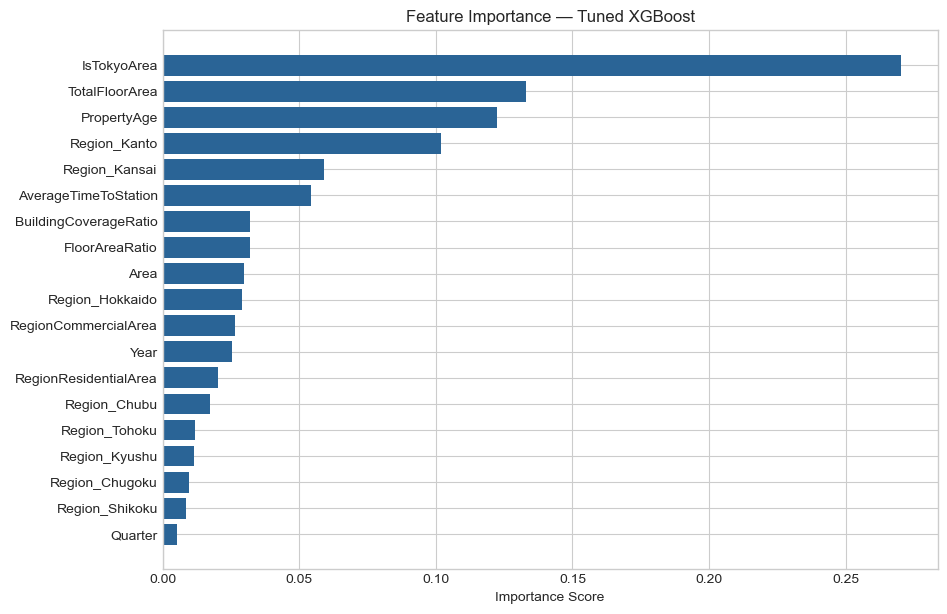

              Feature  Importance
          IsTokyoArea    0.270132
       TotalFloorArea    0.132821
          PropertyAge    0.122524
         Region_Kanto    0.101834
        Region_Kansai    0.059124
 AverageTimeToStation    0.054366
BuildingCoverageRatio    0.032107
       FloorAreaRatio    0.032004
                 Area    0.029733
      Region_Hokkaido    0.029165
 RegionCommercialArea    0.026524
                 Year    0.025362
RegionResidentialArea    0.020283
         Region_Chubu    0.017414
        Region_Tohoku    0.011858
        Region_Kyushu    0.011542
       Region_Chugoku    0.009616
       Region_Shikoku    0.008484
              Quarter    0.005107


In [50]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(importance['Feature'][::-1], 
         importance['Importance'][::-1], 
         color='#2a6496')
plt.title('Feature Importance — Tuned XGBoost')
plt.xlabel('Importance Score')
plt.savefig('visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance.to_string(index=False))

### Observations

Feature importance reveals clear price drivers:

- **IsTokyoArea (27%)** is by far the strongest predictor — 
  location in the Tokyo metropolitan area dominates all other factors
- **TotalFloorArea (13%)** and **PropertyAge (12%)** rank second and third — 
  size and age of the building matter, but less than location
- **AverageTimeToStation (5%)** confirms that proximity to public 
  transport adds significant value
- **Quarter (0.5%)** has minimal impact — property prices in Japan 
  are not strongly seasonal
- Regional features (Kanto, Kansai) add value beyond the Tokyo flag, 
  confirming that location at every level drives price

## 6. Conclusions

### What we built
A machine learning pipeline to predict residential property prices 
across Japan using 20 years of transaction data (1.3M records).

### Key findings
1. **Location is everything** — IsTokyoArea alone accounts for 27% 
   of model's predictive power
2. **Japan's market is historically unique** — prices declined for 
   nearly two decades after the 1991 bubble burst, stabilizing 
   only after 2012 under Abenomics
3. **Okinawa defies expectations** — ranks second in median price 
   due to US military presence, tourism demand, and limited land supply
4. **New buildings command premium prices** — PropertyAge is the 
   third strongest predictor, reflecting Japan's strict post-earthquake 
   building standards
5. **XGBoost outperforms** simpler models with R²=0.661 and RMSE=¥12.76M

### Limitations & next steps
- **Granular location data** (district/neighborhood level) would 
  significantly improve R² — prefecture is too broad
- **Economic indicators** (interest rates, GDP growth) could capture 
  macroeconomic effects better
- **Model deployment** — next step is to wrap the model in a simple 
  API for real-time price predictions

## 7. Saving the Model and Clean Dataset

We save the trained model and cleaned dataset for reuse 
in subsequent notebooks of this series.

In [57]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(xgb_final, 'models/xgb_housing_model.pkl')
joblib.dump(features, 'models/features.pkl')

# Save cleaned dataset for future notebooks
df_clean.to_csv('data/df_clean.csv', index=False)

print("Model saved: models/xgb_housing_model.pkl")
print("Features saved: models/features.pkl")
print(f"Clean dataset saved: data/df_clean.csv ({len(df_clean):,} rows)")
print(f"\nModel can predict prices for {len(features)} features:")
for f in features:
    print(f"  - {f}")

Model saved: models/xgb_housing_model.pkl
Features saved: models/features.pkl
Clean dataset saved: data/df_clean.csv (1,316,373 rows)

Model can predict prices for 19 features:
  - Area
  - TotalFloorArea
  - PropertyAge
  - AverageTimeToStation
  - BuildingCoverageRatio
  - FloorAreaRatio
  - IsTokyoArea
  - Region_Kanto
  - Region_Kansai
  - Region_Chubu
  - Region_Kyushu
  - Region_Tohoku
  - Region_Hokkaido
  - Region_Chugoku
  - Region_Shikoku
  - RegionResidentialArea
  - RegionCommercialArea
  - Year
  - Quarter
